In [1]:
import numpy as np
import pandas as pd
from calc_rates2 import calc_rates
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.metrics import AUC

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


In [2]:
train_set = pd.read_csv("../Data/Net/train_data2.csv")
val_set = pd.read_csv("../Data/Net/val_data2.csv")
test_set = pd.read_csv("../Data/Net/test_data2.csv")

# Poda de columnas y datos

In [3]:
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [4]:
X_train, y_train = remove_labels(train_set, 'result')
X_val, y_val = remove_labels(val_set, 'result')
X_test, y_test = remove_labels(test_set, 'result')

In [5]:
assert(len(X_train) == len(y_train))
print("Entrenamiento:",len(X_train))

assert(len(X_val) == len(y_val))
print("Val:",len(X_val))

assert(len(X_test) == len(y_test))
print("Prueba:",len(X_test))

Entrenamiento: 84830
Val: 47270
Prueba: 52980


In [6]:
columnas_equipo_mudas = ["side","goldat10","goldat15","xpat10","xpat15","avg_dragons_team","avg_barons_team","avg_heralds_team","avg_towers_team","avg_dragons_vs_opp","avg_barons_vs_opp","avg_heralds_vs_opp","avg_towers_vs_opp","wins_vs_opponent"]

In [7]:
X_train_team = X_train[columnas_equipo_mudas]
X_val_team = X_val[columnas_equipo_mudas]
X_test_team = X_test[columnas_equipo_mudas]

In [8]:
print("-"*35)
print(X_train_team.isnull().sum())
print("-"*35)
print(X_val_team.isnull().sum())
print("-"*35)
print(X_test_team.isnull().sum())

-----------------------------------
side                  0
goldat10              0
goldat15              0
xpat10                0
xpat15                0
avg_dragons_team      0
avg_barons_team       0
avg_heralds_team      0
avg_towers_team       0
avg_dragons_vs_opp    0
avg_barons_vs_opp     0
avg_heralds_vs_opp    0
avg_towers_vs_opp     0
wins_vs_opponent      0
dtype: int64
-----------------------------------
side                  0
goldat10              0
goldat15              0
xpat10                0
xpat15                0
avg_dragons_team      0
avg_barons_team       0
avg_heralds_team      0
avg_towers_team       0
avg_dragons_vs_opp    0
avg_barons_vs_opp     0
avg_heralds_vs_opp    0
avg_towers_vs_opp     0
wins_vs_opponent      0
dtype: int64
-----------------------------------
side                  0
goldat10              0
goldat15              0
xpat10                0
xpat15                0
avg_dragons_team      0
avg_barons_team       0
avg_heralds_team      0
av

In [9]:
X_train_team.info()

<class 'pandas.DataFrame'>
RangeIndex: 84830 entries, 0 to 84829
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   side                84830 non-null  bool   
 1   goldat10            84830 non-null  float64
 2   goldat15            84830 non-null  float64
 3   xpat10              84830 non-null  float64
 4   xpat15              84830 non-null  float64
 5   avg_dragons_team    84830 non-null  float64
 6   avg_barons_team     84830 non-null  float64
 7   avg_heralds_team    84830 non-null  float64
 8   avg_towers_team     84830 non-null  float64
 9   avg_dragons_vs_opp  84830 non-null  float64
 10  avg_barons_vs_opp   84830 non-null  float64
 11  avg_heralds_vs_opp  84830 non-null  float64
 12  avg_towers_vs_opp   84830 non-null  float64
 13  wins_vs_opponent    84830 non-null  int64  
dtypes: bool(1), float64(12), int64(1)
memory usage: 8.5 MB


In [10]:
X_train_team.describe()

,goldat10,goldat15,xpat10,xpat15,avg_dragons_team,avg_barons_team,avg_heralds_team,avg_towers_team,avg_dragons_vs_opp,avg_barons_vs_opp,avg_heralds_vs_opp,avg_towers_vs_opp,wins_vs_opponent
count,84830.000000,84830.000000,84830.000000,84830.000000,84830.000000,84830.000000,84830.000000,84830.000000,84830.000000,84830.000000,84830.000000,84830.000000,84830.000000
mean,15517.999402,24504.939024,18335.084838,29338.922900,1.873397,0.691629,0.510084,6.042087,1.662688,0.582331,0.463739,5.064696,3.543157
std,954.798645,1820.033859,864.702961,1482.786239,0.599981,0.213876,0.356368,1.461538,1.126832,0.484049,0.498040,3.152070,5.049577
min,11201.000000,16960.000000,12097.000000,19693.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14893.000000,23281.000000,17827.000000,28414.000000,1.526667,0.605469,0.266667,5.442066,1.000000,0.000000,0.000000,2.800000,0.000000
50%,15441.000000,24256.000000,18395.000000,29392.525000,1.911504,0.714286,0.459459,6.219178,1.750000,0.600000,0.357143,5.590909,2.000000
75%,16038.000000,25532.000000,18889.000000,30285.000000,2.268794,0.804878,0.726316,6.920490,2.428571,0.950000,0.750000,7.333333,5.000000
max,24250.000000,39960.000000,25294.000000,37356.000000,6.000000,4.000000,2.000000,11.000000,8.000000,6.000000,2.333333,11.000000,49.000000


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_team = pd.DataFrame(
    scaler.fit_transform(X_train_team),
    columns=X_train_team.columns,
    index=X_train_team.index)

X_val_team = pd.DataFrame(
    scaler.fit_transform(X_val_team),
    columns=X_val_team.columns,
    index=X_val_team.index)

X_test_team = pd.DataFrame(
    scaler.fit_transform(X_test_team),
    columns=X_test_team.columns,
    index=X_test_team.index)

In [12]:
X_train_team.describe()

,side,goldat10,goldat15,xpat10,xpat15,avg_dragons_team,avg_barons_team,avg_heralds_team,avg_towers_team,avg_dragons_vs_opp,avg_barons_vs_opp,avg_heralds_vs_opp,avg_towers_vs_opp,wins_vs_opponent
count,84830.000000,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04,8.483000e+04
mean,0.000000,1.522436e-15,2.251490e-16,-3.248578e-15,4.181338e-16,4.717407e-16,-7.076111e-16,3.430842e-16,-3.430842e-16,-3.216414e-17,6.968897e-17,2.144276e-17,-1.795831e-16,4.020518e-17
std,1.000006,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-1.000000,-4.521398e+00,-4.145518e+00,-7.214179e+00,-6.505307e+00,-3.122447e+00,-3.233797e+00,-1.431348e+00,-4.134086e+00,-1.475551e+00,-1.203050e+00,-9.311338e-01,-1.606793e+00,-7.016781e-01
25%,-1.000000,-6.545915e-01,-6.724854e-01,-5.875866e-01,-6.237773e-01,-5.779055e-01,-4.028516e-01,-6.830538e-01,-4.105431e-01,-5.881019e-01,-1.203050e+00,-9.311338e-01,-7.184831e-01,-7.016781e-01
50%,0.000000,-8.064512e-02,-1.367779e-01,6.929029e-02,3.614979e-02,6.351523e-02,1.059358e-01,-1.420571e-01,1.211686e-01,7.748484e-02,3.650270e-02,-2.140334e-01,1.669431e-01,-3.056030e-01
75%,1.000000,5.446213e-01,5.643120e-01,6.405881e-01,6.380439e-01,6.590198e-01,5.295117e-01,6.067697e-01,6.010169e-01,6.796824e-01,7.595749e-01,5.747772e-01,7.197335e-01,2.885096e-01
max,1.000000,9.145438e+00,8.491684e+00,8.047800e+00,5.406797e+00,6.877935e+00,1.546871e+01,4.180861e+00,3.392278e+00,5.624041e+00,1.119247e+01,3.753923e+00,1.882997e+00,9.002161e+00


# Red neuronal

In [13]:
print(X_train_team.shape)
print(y_train.unique())

(84830, 14)
[1 0]


In [14]:
num_features = len(X_train_team.columns)

network_team = Sequential([
    # 1. Capa de Entrada (Dependerá de cuántas columnas numéricas te queden)
    Input(shape=(num_features,)), 
    
    # 2. Primer Bloque Oculto
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # 3. Segundo Bloque Oculto
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # 4. Tercer Bloque Oculto
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # 5. Capa de Salida
    Dense(1, activation='sigmoid') 
])

In [15]:
network_team.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           1,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [16]:
network_team.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy', AUC(name='auc')])

In [21]:
history = network_team.fit(X_train_team, 
                      y_train, 
                      epochs=50, 
                      validation_data=(X_val_team, y_val))

Epoch 1/50
2651/2651 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6966 - auc: 0.7697 - loss: 0.5722 - val_accuracy: 0.6848 - val_auc: 0.7617 - val_loss: 0.5776
Epoch 2/50
2651/2651 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6969 - auc: 0.7703 - loss: 0.5714 - val_accuracy: 0.6856 - val_auc: 0.7615 - val_loss: 0.5771
Epoch 3/50
2651/2651 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6971 - auc: 0.7708 - loss: 0.5712 - val_accuracy: 0.6860 - val_auc: 0.7621 - val_loss: 0.5769
Epoch 4/50
2651/2651 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6964 - auc: 0.7704 - loss: 0.5711 - val_accuracy: 0.6826 - val_auc: 0.7597 - val_loss: 0.5778
Epoch 5/50
2651/2651 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6949 - auc: 0.7699 - loss: 0.5718 - val_accuracy: 0.6868 - val_auc: 0.7620 - val_loss: 0.5765
Epoch 6/50
2651/2651 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6950 - auc: 0.7706 - loss: 0.5707 - val_accuracy: 0.6829 - val_auc: 0.7586 - val_loss: 0.5796
Epoch 7/50
2651/2651 ━━━━━━

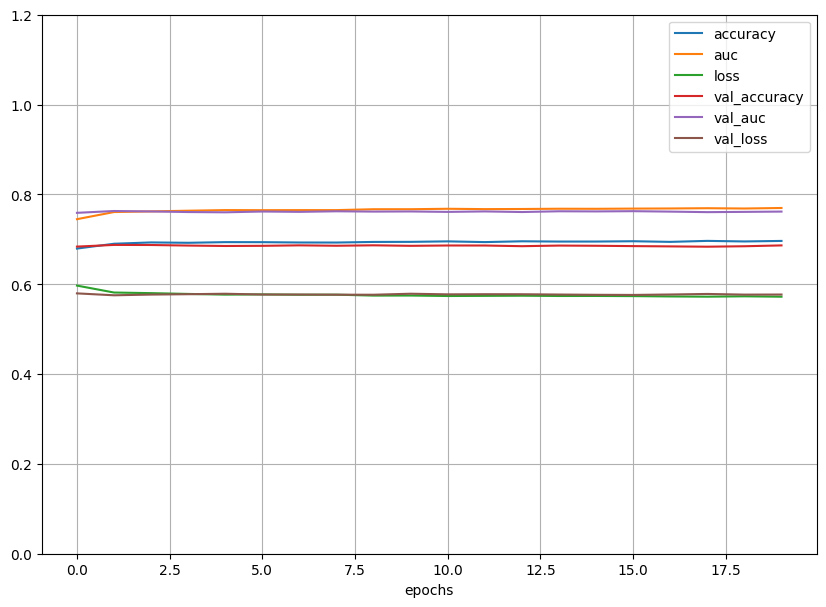

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize=(10, 7))
plt.grid(True)
plt.gca().set_ylim(0, 1.2)
plt.xlabel("epochs")
plt.show()

In [19]:
test_loss, test_acc, test_prec = network_team.evaluate(X_test_team, y_test)

1656/1656 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6635 - auc: 0.7330 - loss: 0.6039


In [20]:
print('test_acc:', test_acc)
print('test_prec:', test_prec)
print('test_loss:', test_loss)

test_acc: 0.6634767651557922
test_prec: 0.7329853177070618
test_loss: 0.6038883328437805
